===== THÔNG TIN WORKLOAD =====
Workload ban đầu: 800
Mức tăng mỗi phút: 230
Số bước thời gian: 198
Workload cuối cùng: 46110

5 giá trị workload đầu tiên:
t = 1: workload = 800
t = 2: workload = 1030
t = 3: workload = 1260
t = 4: workload = 1490
t = 5: workload = 1720

5 giá trị workload cuối cùng:
t = 194: workload = 45190
t = 195: workload = 45420
t = 196: workload = 45650
t = 197: workload = 45880
t = 198: workload = 46110

KẾT QUẢ MÔ PHỎNG
Số dòng dữ liệu: 198
VM ban đầu: 1
VM cuối cùng: 44
Response Time nhỏ nhất: 87.20 ms
Response Time lớn nhất: 296.67 ms

10 dòng dữ liệu đầu tiên:
   minute  requests  response_time  vms_count
0       1       800     106.002131          1
1       2      1030     193.339864          1
2       3      1260     296.673051          1
3       4      1490      87.204522          2
4       5      1720     127.389443          2
5       6      1950     171.099570          2
6       7      2180     218.644151          2
7       8      2410     107.165859    

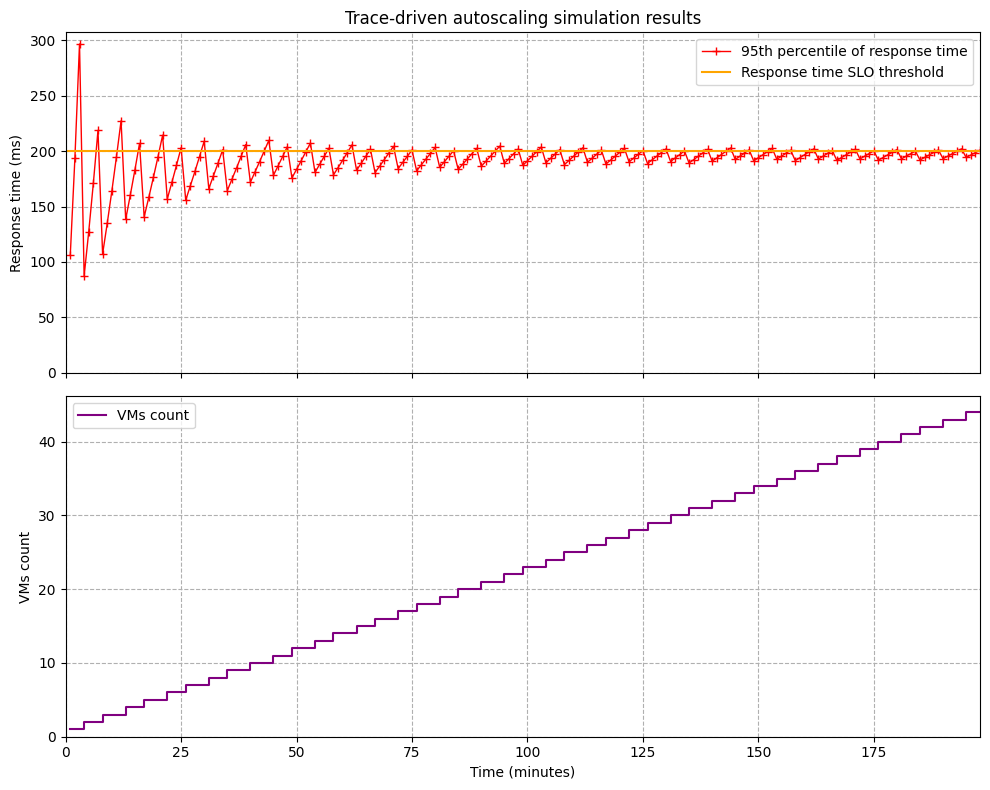

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# BƯỚC 1: CẤU HÌNH THAM SỐ HỆ THỐNG
# ============================================================

# Các tham số của mô hình Response Time
A_PARAM = 265.68214
B_PARAM = -0.0007312
C_PARAM = -370.87584

# Ngưỡng SLO Response Time
TAU_SLO = 200            # ms
# Ngưỡng để thực hiện Scale-in
SCALE_IN_LIMIT = 100     # ms
# Chu kỳ giám sát
MONITORING_WINDOW = 1   # phút
# ============================================================
# HÀM TÍNH RESPONSE TIME
# ============================================================
def get_response_time(total_requests, num_vms):
    """
    Tính toán Response Time dựa trên mô hình hàm mũ.

    n_t = total_requests / num_vms

    RT = A * exp(-B * n_t) + C
    """

    # Số request trên mỗi VM
    n_t = total_requests / num_vms

    # Tính Response Time
    rt = A_PARAM * np.exp(-B_PARAM * n_t) + C_PARAM

    # Đảm bảo Response Time không nhỏ hơn 10 ms
    return max(10, rt)
# ============================================================
# BƯỚC 2: XÂY DỰNG WORKLOAD THEO CÔNG THỨC
#
#             w_i(t) = w_i(t0) + (t - 1) * Δw_i
# ============================================================
DURATION = 198
# Các mốc thời gian:
# t = 1, 2, 3, ..., 198
time_steps = np.arange(1, DURATION + 1)
# ------------------------------------------------------------
# Tham số của công thức workload
# ------------------------------------------------------------
# w_i(t0): workload tại thời điểm ban đầu
W_INITIAL = 800
# Δw_i: mức tăng workload sau mỗi bước thời gian
DELTA_W = 230
# ------------------------------------------------------------
# Áp dụng công thức:
# w_i(t) = w_i(t0) + (t - 1) * Δw_i
# ------------------------------------------------------------
workload = W_INITIAL + (time_steps - 1) * DELTA_W
# ============================================================
# KIỂM TRA WORKLOAD
# ============================================================
print("===== THÔNG TIN WORKLOAD =====")
print(f"Workload ban đầu: {W_INITIAL}")
print(f"Mức tăng mỗi phút: {DELTA_W}")
print(f"Số bước thời gian: {DURATION}")
print(f"Workload cuối cùng: {workload[-1]}")

print("\n5 giá trị workload đầu tiên:")
for t, w in zip(time_steps[:5], workload[:5]):
    print(f"t = {t}: workload = {w}")

print("\n5 giá trị workload cuối cùng:")
for t, w in zip(time_steps[-5:], workload[-5:]):
    print(f"t = {t}: workload = {w}")

# ============================================================
# BƯỚC 3: MÔ PHỎNG REACTIVE AUTOSCALING
# ============================================================
# Số VM ban đầu
current_vms = 1

# Danh sách lưu dữ liệu mô phỏng
data_log = []

# Bộ đếm điều kiện Scale-in
# Cần 3 chu kỳ liên tiếp có RT < 100 ms
scale_in_counter = 0


# ============================================================
# VÒNG LẶP MÔ PHỎNG
# ============================================================

for t in range(DURATION):

    # Workload tại thời điểm hiện tại
    w_t = workload[t]

    # --------------------------------------------------------
    # Tính Response Time
    # --------------------------------------------------------

    r_t = get_response_time(
        total_requests=w_t,
        num_vms=current_vms
    )

    # --------------------------------------------------------
    # Lưu trạng thái TRƯỚC khi thực hiện quyết định scale
    # --------------------------------------------------------

    data_log.append({
        "minute": t + 1,
        "requests": w_t,
        "response_time": r_t,
        "vms_count": current_vms
    })

    # ========================================================
    # LOGIC AUTOSCALING
    # ========================================================

    # --------------------------------------------------------
    # SCALE-OUT
    # Nếu Response Time vượt SLO
    # --------------------------------------------------------

    if r_t > TAU_SLO:

        # Tăng thêm 1 VM
        current_vms += 1

        # Reset bộ đếm Scale-in
        scale_in_counter = 0

    # --------------------------------------------------------
    # SCALE-IN
    # Nếu Response Time thấp hơn ngưỡng Scale-in
    # --------------------------------------------------------

    elif r_t < SCALE_IN_LIMIT:

        # Tăng bộ đếm
        scale_in_counter += 1

        # Nếu có 3 chu kỳ liên tiếp thỏa điều kiện
        if scale_in_counter >= 3:

            # Không giảm xuống dưới 1 VM
            if current_vms > 1:
                current_vms -= 1

            # Reset bộ đếm
            scale_in_counter = 0

    # --------------------------------------------------------
    # Vùng giữa Scale-in và Scale-out
    # --------------------------------------------------------

    else:

        scale_in_counter = 0


# ============================================================
# BƯỚC 4: TẠO DATAFRAME
# ============================================================

df_sim = pd.DataFrame(data_log)


# ============================================================
# HIỂN THỊ THÔNG TIN MÔ PHỎNG
# ============================================================

print("\n========================================")
print("KẾT QUẢ MÔ PHỎNG")
print("========================================")

print(f"Số dòng dữ liệu: {len(df_sim)}")

print(f"VM ban đầu: 1")
print(f"VM cuối cùng: {df_sim['vms_count'].iloc[-1]}")

print(
    f"Response Time nhỏ nhất: "
    f"{df_sim['response_time'].min():.2f} ms"
)

print(
    f"Response Time lớn nhất: "
    f"{df_sim['response_time'].max():.2f} ms"
)

print("\n10 dòng dữ liệu đầu tiên:")
print(df_sim.head(10))


# ============================================================
# BƯỚC 5: XUẤT DỮ LIỆU HUẤN LUYỆN
# ============================================================

output_csv = "../data/simulation_data_198.csv"

df_sim.to_csv(
    output_csv,
    index=False
)

print(
    f"\nĐã lưu {len(df_sim)} dòng dữ liệu vào:"
    f"\n{output_csv}"
)


# ============================================================
# BƯỚC 6: VẼ BIỂU ĐỒ
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True
)

max_minute = df_sim["minute"].max()


# ============================================================
# BIỂU ĐỒ 1: RESPONSE TIME
# ============================================================

ax1.plot(
    df_sim["minute"],
    df_sim["response_time"],
    color="red",
    marker="+",
    label="95th percentile of response time",
    linewidth=1
)

# Đường SLO = 200 ms
ax1.axhline(
    y=TAU_SLO,
    color="orange",
    linestyle="-",
    label="Response time SLO threshold"
)

ax1.set_ylabel("Response time (ms)")

ax1.set_title(
    "Trace-driven autoscaling simulation results"
)

ax1.legend()

ax1.grid(
    True,
    linestyle="--"
)

# Trục X bắt đầu từ 0
ax1.set_xlim(
    left=0,
    right=max_minute
)

# Trục Y bắt đầu từ 0
ax1.set_ylim(
    bottom=0
)


# ============================================================
# BIỂU ĐỒ 2: SỐ LƯỢNG VM
# ============================================================

ax2.step(
    df_sim["minute"],
    df_sim["vms_count"],
    color="purple",
    where="post",
    label="VMs count"
)

ax2.set_ylabel("VMs count")

ax2.set_xlabel("Time (minutes)")

ax2.legend()

ax2.grid(
    True,
    linestyle="--"
)

# Trục X bắt đầu từ 0
ax2.set_xlim(
    left=0,
    right=max_minute
)

# Trục Y bắt đầu từ 0
ax2.set_ylim(
    bottom=0
)


# ============================================================
# BƯỚC 7: LƯU HÌNH
# ============================================================

plt.tight_layout()

output_png = "../data/simulation_198.png"

plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight"
)

print(
    f"Đã lưu biểu đồ vào:"
    f"\n{output_png}"
)

plt.show()

Đã lưu biểu đồ vào:
../data/simulation_198_2.png


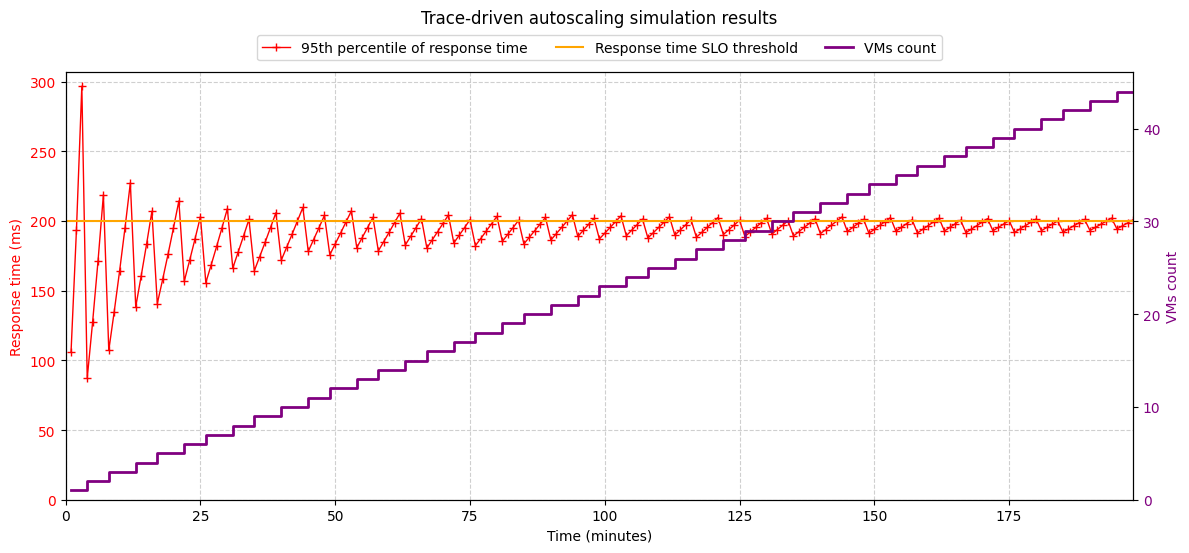

In [10]:
# ============================================================
# BƯỚC 6: VẼ 2 ĐỒ THỊ LỒNG VÀO NHAU
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

max_minute = df_sim["minute"].max()

# ============================================================
# RESPONSE TIME - TRỤC Y BÊN TRÁI
# ============================================================

ax1.plot(
    df_sim["minute"],
    df_sim["response_time"],
    color="red",
    marker="+",
    linewidth=1,
    label="95th percentile of response time"
)

ax1.axhline(
    y=TAU_SLO,
    color="orange",
    linestyle="-",
    label="Response time SLO threshold"
)

ax1.set_xlabel("Time (minutes)")
ax1.set_ylabel("Response time (ms)", color="red")

ax1.tick_params(
    axis="y",
    labelcolor="red"
)

ax1.set_xlim(0, max_minute)
ax1.set_ylim(bottom=0)

ax1.grid(
    True,
    linestyle="--",
    alpha=0.6
)

# ============================================================
# VM COUNT - TRỤC Y BÊN PHẢI
# ============================================================

ax2 = ax1.twinx()

ax2.step(
    df_sim["minute"],
    df_sim["vms_count"],
    color="purple",
    where="post",
    linewidth=2,
    label="VMs count"
)

ax2.set_ylabel(
    "VMs count",
    color="purple"
)

ax2.tick_params(
    axis="y",
    labelcolor="purple"
)

ax2.set_ylim(bottom=0)

# ============================================================
# GỘP LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=True
)

# ============================================================
# TIÊU ĐỀ
# ============================================================

plt.title(
    "Trace-driven autoscaling simulation results",
    pad=35
)

# Chừa khoảng trống phía trên cho legend
plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

# ============================================================
# LƯU HÌNH
# ============================================================

output_png = "../data/simulation_198_2.png"

plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight"
)

print(
    f"Đã lưu biểu đồ vào:"
    f"\n{output_png}"
)

plt.show()